# Chronos-T5 — Benchmark II Reproduction (zero-shot + one-shot)

**Saudi Aramco — time-series foundation-model evaluation**

A faithful reproduction of the **Chronos paper's Benchmark II** (Ansari et al.,
2024, *Chronos: Learning the Language of Time Series*, TMLR), evaluating
`amazon/chronos-t5-small` on the paper's zero-shot datasets under two scenarios:

* **zero-shot** — pretrained weights used as-is;
* **one-shot** — pretrained weights fine-tuned per dataset (lr 1e-3 → 0 over 1000
  steps), as in the paper's Section 5.5.2 / Figure 6.

The evaluation reuses the **official Chronos method** so the numbers are directly
comparable to the paper:
* backtest windows via `gluonts.dataset.split`,
* metrics via gluonts `MASE` + `MeanWeightedSumQuantileLoss`,
* the **aggregated relative score** (geometric mean of `model / Seasonal-Naive`).

> Heavy stages are produced offline by `src/zero_shot/run_zeroshot_official.py`,
> `src/one_shot/finetune_oneshot.py`, `src/one_shot/run_oneshot_official.py`; this notebook loads
> their results from `results/*.csv` and shows one small live zero-shot demo.
> Only deviation from the paper: a 1000-series cap for laptop tractability.


## 1. Environment & imports

Reusable logic is imported from `src/` (`config`, `datasets_lib`,
`run_zeroshot_official`); the notebook only orchestrates and displays.

In [1]:
import sys, platform, warnings
from pathlib import Path

# Quiet noisy library warnings (tqdm/gluonts FutureWarnings, HF cache notices) so
# cell output stays clean and free of machine-specific cache/site-package paths.
warnings.filterwarnings("ignore")
import datasets; datasets.logging.set_verbosity_error(); datasets.disable_progress_bars()

# Locate the project root portably (walk up to the dir containing src/config.py).
_here = Path.cwd()
for _c in (_here, *_here.parents):
    if (_c / "src" / "config.py").exists():
        ROOT = _c; break
else:
    raise FileNotFoundError("project root (src/config.py) not found from " + str(_here))
SRC = ROOT / "src"; [sys.path.insert(0, str(SRC / p)) for p in ("", "zero_shot", "one_shot")]

import numpy as np, pandas as pd, torch
from scipy.stats import gmean
import chronos
from chronos import BaseChronosPipeline
import datasets as hfds
from gluonts.dataset.split import split
from gluonts.ev.metrics import MASE, MeanWeightedSumQuantileLoss
from gluonts.model.evaluation import evaluate_forecasts

from config import RESULTS_DIR as RESULTS
import datasets_lib as D
import run_zeroshot_official as R   # to_gluonts_univariate / chronos_forecasts / REFERENCE_DIR

print("Python  :", platform.python_version())
print("torch   :", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("chronos :", chronos.__version__)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

Python  : 3.11.15
torch   : 2.9.1+cu128 | CUDA: True
chronos : 2.2.2


## 2. Datasets — Benchmark II

25 of the paper's 27 Benchmark II (zero-shot) datasets from
`autogluon/chronos_datasets` (the 2 ETT datasets are absent from that repo).
Per-dataset horizon = paper Table 3; one held-out last-H window; seasonality is
inferred from each dataset's frequency by gluonts.

In [2]:
bench = pd.DataFrame(D.BENCHMARK_II, columns=["dataset", "horizon"])
print(f"{len(bench)} datasets, series cap = {D.MAX_SERIES}")
bench

25 datasets, series cap = 1000


,dataset,horizon
0,monash_australian_electricity,48
1,monash_cif_2016,12
2,monash_car_parts,12
3,monash_covid_deaths,30
4,dominick,8
5,ercot,24
6,exchange_rate,30
7,monash_fred_md,12
8,monash_hospital,12
9,monash_m1_monthly,18


## 3. Method (one cell, the shared engine)

For every dataset the same pipeline runs: build gluonts backtest windows →
`predict_quantiles` (20 samples) → gluonts `MASE` / `WQL`. Below is a **live
zero-shot demo** on one small dataset (`exchange_rate`, 8 series) so real output
appears inline; the full 25-dataset sweep is loaded in Section 4.

In [3]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if dev == "cuda" else torch.float32
pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-t5-small", device_map=dev, torch_dtype=dtype)

cfg, h = "exchange_rate", 30
ds = hfds.load_dataset(R.HF_REPO, cfg, split="train"); ds.set_format("numpy")
gts = R.to_gluonts_univariate(ds, R.MAX_SERIES)
_, tt = split(gts, offset=-h); td = tt.generate_instances(h, windows=1)
fc = R.chronos_forecasts(pipe, td.input, h)
m = (evaluate_forecasts(fc, test_data=td,
        metrics=[MASE(), MeanWeightedSumQuantileLoss(R.QUANTILES)], batch_size=5000)
     .reset_index(drop=True).to_dict("records")[0])
print(f"live zero-shot demo  {cfg}:  MASE={m['MASE[0.5]']:.4f}  WQL={m['mean_weighted_sum_quantile_loss']:.4f}")
del pipe
if dev == "cuda": torch.cuda.empty_cache()

`torch_dtype` is deprecated! Use `dtype` instead!


0it [00:00, ?it/s]

8it [00:00, 339.89it/s]

live zero-shot demo  exchange_rate:  MASE=1.9954  WQL=0.0138


## 4. Full results (precomputed, both scenarios)

Loaded from `results/` — the canonical numbers from the offline runs.

In [4]:
zs = pd.read_csv(RESULTS / "zeroshot_official_results.csv")[["dataset", "MASE", "WQL", "n_series"]]
os_ = pd.read_csv(RESULTS / "oneshot_official_results.csv")[["dataset", "MASE", "WQL"]]
res = zs.merge(os_, on="dataset", suffixes=("_zero", "_one"))
res = res[["dataset", "n_series", "MASE_zero", "MASE_one", "WQL_zero", "WQL_one"]]
res

,dataset,n_series,MASE_zero,MASE_one,WQL_zero,WQL_one
0,monash_australian_electricity,5,1.1849,0.8713,0.0724,0.0398
1,monash_cif_2016,72,1.0017,0.9850,0.0115,0.0109
2,monash_car_parts,1000,0.8768,0.8068,1.0505,0.9255
3,monash_covid_deaths,266,42.7023,33.6336,0.0673,0.0303
4,dominick,1000,0.9398,0.9560,0.3686,0.3586
5,ercot,8,0.5922,0.5972,0.0170,0.0193
6,exchange_rate,8,1.9954,1.5661,0.0138,0.0110
7,monash_fred_md,107,0.4533,0.5336,0.0149,0.0283
8,monash_hospital,767,0.8068,0.7950,0.0583,0.0595
9,monash_m1_monthly,617,1.1712,1.0458,0.1454,0.1675


### 4.1 Inference efficiency (latency + peak GPU memory)

Beyond accuracy, each run records the per-dataset forecast **wall-time** and
**peak GPU memory** (`chronos-t5-small`, bf16). These are the baseline numbers a
future model (e.g. Chronos-2) must be compared against on speed/footprint, not
just WQL/MASE.

In [5]:
cols = ["dataset", "n_series", "latency_s", "ms_per_series", "peak_mem_mb"]
eff_zs = pd.read_csv(RESULTS / "zeroshot_official_results.csv")[cols]
eff_os = pd.read_csv(RESULTS / "oneshot_official_results.csv")[cols].drop(columns="n_series")
eff = eff_zs.merge(eff_os, on="dataset", suffixes=("_zero", "_one"))
for sc in ("zero", "one"):
    print(f"{sc:>4}-shot: total {eff[f'latency_s_{sc}'].sum():6.1f}s   "
          f"peak {eff[f'peak_mem_mb_{sc}'].max():5.0f} MB   "
          f"mean {eff[f'ms_per_series_{sc}'].mean():5.1f} ms/series")
eff

zero-shot: total  202.4s   peak  5581 MB   mean  29.2 ms/series
 one-shot: total  248.1s   peak  5581 MB   mean  51.8 ms/series


,dataset,n_series,latency_s_zero,ms_per_series_zero,peak_mem_mb_zero,latency_s_one,ms_per_series_one,peak_mem_mb_one
0,monash_australian_electricity,5,1.1390,227.8100,891.5000,2.8280,565.6800,891.5000
1,monash_cif_2016,72,0.9070,12.6000,"1,235.3000",1.5130,21.0100,"1,235.3000"
2,monash_car_parts,1000,7.7240,7.7200,702.2000,15.5560,15.5600,702.2000
3,monash_covid_deaths,266,4.3760,16.4500,"2,090.9000",11.5340,43.3600,"2,090.9000"
4,dominick,1000,10.7390,10.7400,"4,154.3000",13.1100,13.1100,"4,154.3000"
5,ercot,8,0.7430,92.8600,"1,576.8000",1.1100,138.7900,"1,576.8000"
6,exchange_rate,8,0.5380,67.2100,"1,618.7000",1.2830,160.3500,"1,618.7000"
7,monash_fred_md,107,1.4990,14.0100,"5,455.5000",2.0430,19.0900,"5,455.5000"
8,monash_hospital,767,6.7190,8.7600,"1,226.6000",11.8770,15.4900,"1,226.6000"
9,monash_m1_monthly,617,13.7000,22.2000,"1,833.9000",14.6180,23.6900,"1,833.9000"


## 5. Comparison to the paper + aggregated relative score

The headline metric: geometric mean of `model / Seasonal-Naive` across datasets
(the paper's aggregation). Reference Seasonal-Naive and Chronos-T5 Small numbers
come from the official chronos-forecasting repo. Paper one-shot is the Figure 6
aggregate (WQL 0.597, MASE 0.760).

In [6]:
zsi = pd.read_csv(RESULTS / "zeroshot_official_results.csv").set_index("dataset")[["MASE", "WQL"]]
osi = pd.read_csv(RESULTS / "oneshot_official_results.csv").set_index("dataset")[["MASE", "WQL"]]
base  = pd.read_csv(R.REFERENCE_DIR / "seasonal-naive-zero-shot.csv").set_index("dataset")[["MASE", "WQL"]]
paper = pd.read_csv(R.REFERENCE_DIR / "chronos-t5-small-zero-shot.csv").set_index("dataset")[["MASE", "WQL"]]
common = zsi.index.intersection(base.index)

def agg(df): return (df.loc[common] / base.loc[common]).apply(gmean)
headline = pd.DataFrame({
    "WQL_ours":  [agg(zsi)["WQL"],  agg(osi)["WQL"]],
    "WQL_paper": [agg(paper)["WQL"], 0.597],
    "MASE_ours": [agg(zsi)["MASE"], agg(osi)["MASE"]],
    "MASE_paper":[agg(paper)["MASE"], 0.760],
}, index=["zero-shot", "one-shot"])
print("Aggregated relative score (gmean of model / Seasonal-Naive):")
headline.round(3)

Aggregated relative score (gmean of model / Seasonal-Naive):


,WQL_ours,WQL_paper,MASE_ours,MASE_paper
zero-shot,0.6870,0.6750,0.8520,0.8390
one-shot,0.6150,0.5970,0.7660,0.7600


### 5.1 Per-dataset: ours vs paper (zero-shot, Chronos-T5 Small)

In [7]:
cmp = zsi.loc[common].join(paper.loc[common], lsuffix="_ours", rsuffix="_paper")
cmp[["WQL_ours", "WQL_paper", "MASE_ours", "MASE_paper"]].round(4)

,WQL_ours,WQL_paper,MASE_ours,MASE_paper
dataset,,,,
monash_australian_electricity,0.0724,0.0695,1.1849,1.2241
monash_cif_2016,0.0115,0.0146,1.0017,1.0188
monash_car_parts,1.0505,1.0315,0.8768,0.8918
monash_covid_deaths,0.0673,0.0634,42.7023,42.2990
dominick,0.3686,0.3368,0.9398,0.8109
ercot,0.0170,0.0155,0.5922,0.5649
exchange_rate,0.0138,0.0145,1.9954,1.8143
monash_fred_md,0.0149,0.0149,0.4533,0.4742
monash_hospital,0.0583,0.0570,0.8068,0.7098


## 6. Charts

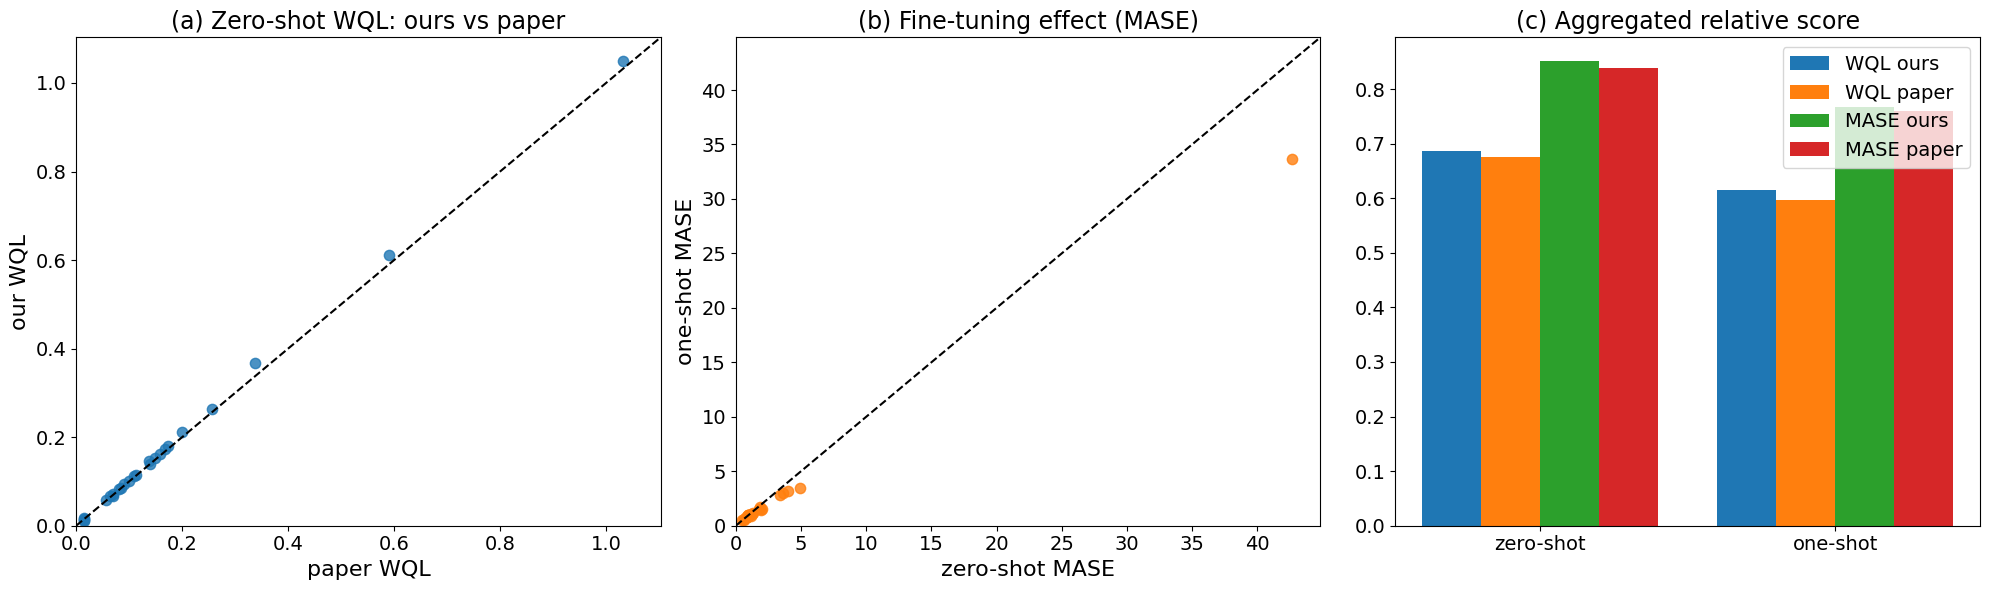

In [8]:
import matplotlib.pyplot as plt

# Larger, readable typography across all three panels.
LABEL_FS, TITLE_FS, TICK_FS, LEGEND_FS = 16, 17, 14, 14

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# (a) ours vs paper, zero-shot WQL — points on the diagonal = faithful reproduction
ax[0].scatter(paper.loc[common, "WQL"], zsi.loc[common, "WQL"], s=55, alpha=0.8)
lim = [0, max(paper.loc[common, "WQL"].max(), zsi.loc[common, "WQL"].max()) * 1.05]
ax[0].plot(lim, lim, "k--", lw=1.5); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("paper WQL", fontsize=LABEL_FS); ax[0].set_ylabel("our WQL", fontsize=LABEL_FS)
ax[0].set_title("(a) Zero-shot WQL: ours vs paper", fontsize=TITLE_FS)

# (b) zero-shot vs one-shot MASE per dataset (below diagonal = fine-tuning helped)
ax[1].scatter(zsi.loc[common, "MASE"], osi.loc[common, "MASE"], s=55, alpha=0.8, color="C1")
lim2 = [0, max(zsi.loc[common, "MASE"].max(), osi.loc[common, "MASE"].max()) * 1.05]
ax[1].plot(lim2, lim2, "k--", lw=1.5); ax[1].set_xlim(lim2); ax[1].set_ylim(lim2)
ax[1].set_xlabel("zero-shot MASE", fontsize=LABEL_FS); ax[1].set_ylabel("one-shot MASE", fontsize=LABEL_FS)
ax[1].set_title("(b) Fine-tuning effect (MASE)", fontsize=TITLE_FS)

# (c) aggregated relative score bars
x = np.arange(2); w = 0.2
ax[2].bar(x - 1.5*w, headline["WQL_ours"],  w, label="WQL ours")
ax[2].bar(x - 0.5*w, headline["WQL_paper"], w, label="WQL paper")
ax[2].bar(x + 0.5*w, headline["MASE_ours"], w, label="MASE ours")
ax[2].bar(x + 1.5*w, headline["MASE_paper"],w, label="MASE paper")
ax[2].set_xticks(x); ax[2].set_xticklabels(["zero-shot", "one-shot"], fontsize=TICK_FS)
ax[2].set_title("(c) Aggregated relative score", fontsize=TITLE_FS)
ax[2].legend(fontsize=LEGEND_FS)

# Enlarge tick labels on every axis.
for a in ax:
    a.tick_params(axis="both", which="major", labelsize=TICK_FS)

fig.tight_layout(); plt.show()

## 7. Findings

* **Zero-shot reproduces the paper closely** — aggregated relative score WQL 0.687
  vs 0.675, MASE 0.852 vs 0.839; per-dataset points lie on the diagonal (chart a).
* **One-shot fine-tuning improves the aggregate, matching the paper** — WQL
  0.687→0.615, MASE 0.852→0.766 (paper: 0.675→0.597, 0.839→0.760). Most datasets
  move below the diagonal in chart (b).
* **Method is paper-faithful**: gluonts metrics + split, seasonality auto-inferred,
  no series-length filtering; the fine-tuning is an explicit PyTorch loop
  (`src/one_shot/finetune_oneshot.py`), not `train.py` or HF `Trainer`.
* **Residual gap** to the paper is from the 1000-series cap (paper uses full data)
  and a single seed.
* **Efficiency baseline recorded** (Section 4.1): per-dataset forecast latency and
  peak GPU memory for chronos-t5-small (bf16), so future models are compared on
  speed/footprint too, not only accuracy.

**For Chronos-2:** point `run_zeroshot_official.py` at `amazon/chronos-2` and run
the identical pipeline; it must beat these per-dataset WQL/MASE and the aggregated
relative score **at comparable or better latency/memory** (Section 4.1).
